In [3]:
from numpy import count_nonzero,arange,array,dot,asarray,zeros,apply_along_axis,around,sort,shape,savetxt,array_equal,max,argmin,argmax,fill_diagonal,ones,argsort,std,mean,median,diag,random,diff
from matplotlib.pyplot import plot,figure,title,legend,xlabel,ylabel,grid,axvline,savefig,imshow,show,scatter,hist,bar,subplot,subplots,text,axhline,stem,xticks,annotate,setp,axes
from math import sqrt,exp,dist
import pandas as pd
from datetime import datetime,timedelta
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score,calinski_harabasz_score,davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from dtaidistance import dtw
from aeon.distances import msm_distance
import seaborn as sns
import matplotlib.patches as mpatches
from statsmodels.tsa.stattools import adfuller,grangercausalitytests
import statsmodels.api as sm
import geopandas

# Funciones implementadas

In [4]:
def aumentar_fecha(fecha_ini,dias):
    date = datetime(int(fecha_ini[0:4]),int(fecha_ini[5:7]),int(fecha_ini[8:10]))
    new_date = date+timedelta(days=dias)
    new_str = str(new_date)
    fecha_fin = new_str[0:10]
    return fecha_fin

#Convertir las filas de una matriz en listas
def conv_to_list(matriz):
    n,m = shape(matriz)
    listas = []
    for i in range(0,n):
        fila_act = matriz[i,:]
        listas.append(fila_act.tolist())
    return listas

#n es el número de municipios totales
def fill_mat(etiq,conteo,n):
    out = zeros((n))
    m = len(conteo)
    for i in range(0,m):
        out[etiq[i]-1] = conteo[i]
    return out

#Construir matriz de series de tiempo por cluster
def clust_ser(clust,mat_data):
    #El número de filas es acorde con el número de clusters
    n = len(clust)
    #El número de columnas es igual al de las columnas de mat_data
    m1,m2 = shape(mat_data)
    #Construir matriz de salida
    mat_clust = zeros((n,m2))
    for i in range(0,m2):
        for j in range(0,n):
            clust_act = clust[j]
            suma = 0
            n1 = len(clust_act)
            for k in range(0,n1):
                suma += mat_mun[clust_act[k],i]
            mat_clust[j,i] = suma
    return mat_clust

#Realizar medias móviles centradas de k días
def media_movil(x_fil, k=7):
    x = x_fil.tolist()
    n = len(x)-(k-1)
    suav = zeros((n))
    step = int((k-1)/2)
    for i in range(step,n+step):
        suav[i-step] = sum(x[i-step:i+step+1])/k
    out = asarray(suav)
    return out

#Realizar medias móviles centradas de k días
def mediana_movil(x_fil, k=7):
    x = x_fil.tolist()
    n = len(x)-(k-1)
    suav = zeros((n))
    step = int((k-1)/2)
    for i in range(step,n+step):
        suav[i-step] = median(x[i-step:i+step+1])
    out = asarray(suav)
    return out

Separar etiquetas de acuerdo al clúster asignado

In [5]:
def sep_clust(etiq_kmeans,n_clust):
    clust_sep = []
    for k in range(0,n_clust):
        clust_sep.append([])
    n = len(etiq_kmeans)
    for i in range(0,n):
        com_act = clust_sep[etiq_kmeans[i]]
        com_act.append(i)
    return clust_sep

#Imprimir el nombre de los estados que conforman cada comunidad
#k es el número de clusters
def imp_names(clusters,etiq):
    n = len(clusters)
    #Crear tantas listas como clusters
    names_clust = []
    for i in range(0,n):
        names_clust.append([])
    for j in range(0,n):
        clust_act = clusters[j]
        name_act = names_clust[j]
        k = len(clust_act)
        for l in range(0,k):
            name_act.append(etiq[clust_act[l]])
    for ii in range(0,n):
        print("Cluster "+str(ii))
        print(names_clust[ii])
    return

Calcular la matriz de distancias basándose en la métrica Euclidiana, la métrica MSM o la función DTW

In [6]:
#Matriz para almacenar la distancia euclidiana entre cada par de series de tiempo
def matriz_euclid(series):
    #n es el número de observaciones de cada serie de tiempo
    #m es el número de series de tiempo
    n,m = shape(series)
    #Matriz de ceros para guardar las distancias entre cada par de series de tiempo
    M = zeros((m,m))
    for i in range(0,m):
        for j in range(i+1,m):
            M[i,j] = dist(series[:,i], series[:,j])
    return M+M.T

#Matriz para almacenar la función DTW entre cada par de series de tiempo
def matriz_dtw(series):
    M = dtw.distance_matrix_fast(series.T)
    return M 

#Matriz para almacenar la métrica MSM entre las series de tiempo
def matriz_msm(series):
    #n es el número de observaciones de cada serie de tiempo
    #m es el número de series de tiempo
    n,m = shape(series)
    #Matriz de ceros para guardar las distancias entre cada par de series de tiempo
    M = zeros((m,m))
    for i in range(0,m):
        for j in range(i+1,m):
            x,y = series[:,i].copy(),series[:,j].copy()
            M[i,j] = msm_distance(x, y)
    return M+M.T

Lista de colores para definir grupos

In [7]:
list_colors=['red','darkorange','blue','royalblue','gold','magenta','green','hotpink','navy','purple','yellow','cyan','brown','olive','lime','silver',
             'gray','crimson','salmon','lawngreen','darkred','crimson','lightgreen','tan','indigo','violet','black','orange','chocolate','steelblue',
             'greenyellow','peru']

#Importar datos geométricos y de posición para crear mapas de los estados de México

In [8]:
mun_mex_map = geopandas.read_file('Mexico_Estados.shp')

In [9]:
mun_mex_map.head()

,CODIGO,ESTADO,geometry
0,MX02,Baja California,"MULTIPOLYGON (((-113.13972 29.01778, -113.2405..."
1,MX03,Baja California Sur,"MULTIPOLYGON (((-111.20612 25.80278, -111.2302..."
2,MX18,Nayarit,"MULTIPOLYGON (((-106.62108 21.56531, -106.6475..."
3,MX14,Jalisco,"POLYGON ((-101.5249 21.85664, -101.5883 21.772..."
4,MX01,Aguascalientes,"POLYGON ((-101.8462 22.01176, -101.9653 21.883..."


#Implementar funciones para el manejo de los mapas

In [10]:
def transf(com):
    #Etiquetas de los municipios que maneja el archivos shp del INEGI
    new_etiq = [4,0,1,14,21,23,10,24,11,26,5,18,7,3,9,8,12,2,29,19,15,6,16,28,25,22,20,30,17,31,13,27]
    n_com = len(com)
    new_com = []
    for i in range(0,n_com):
        new_com.append([])
        com_act = com[i]
        n_act = len(com_act)
        new_com_act = new_com[i]
        for j in range(0,n_act):
            new_com_act.append(new_etiq[com_act[j]])
    return new_com

#Cambiar las listas de comunidades por una sola lista con el número de grupo de cada estado
def com_to_group(com):
    n_com = len(com)
    groups=zeros((32))
    for i in range(0,n_com):
        com_act = com[i]
        n_act = len(com[i])
        for j in range(0,n_act):
            groups[com_act[j]] = i
    groups_out = groups.tolist()
    return groups_out

#Cambiar etiquetas de grupos por nombres de los colores correspondientes
def change(groups,colors):
    n=len(groups)
    colors_out=[]
    for i in range(0,n):
        colors_out.append(colors[int(groups[i])])
    return colors_out

def generar_patches(colores):
    lista_patches = []
    n_colors=len(colores)
    for i in range(0,n_colors):
        patch_act = mpatches.Patch(color=colores[i],label='Community '+str(i))
        lista_patches.append(patch_act)
    return lista_patches

def transf_casos_est(casos_est):
    #Etiquetas de los estados que maneja el archivos shp del INEGI
    new_etiq = [4,0,1,14,21,23,10,24,11,26,5,18,7,3,9,8,12,2,29,19,15,6,16,28,25,22,20,30,17,31,13,27]
    n_est = len(new_etiq)
    new_com = zeros((n_est))
    for i in range(0,n_est):
           new_com[new_etiq[i]] = casos_est[i]
    return new_com

#Importar datos de casos de incidencia

In [11]:
df = pd.read_csv('Casos_Estado_Confirmados_20230625.csv')
#Borrar registros con valor nulo
df = df.dropna()
print("Tamaño de la base de datos:")
print(df.shape)
print("Información general de los datos:")
print(df.info())
#Cuántos diferentes valores posee cada variable
print("Cantidad de valores diferentes para cada variable:")
print(df.nunique())

print()
#Verificar si hay valores nulos
print("Valores nulos en cada variable")
print(df.isnull().sum())
#Guardar etiquetas de los nombres de los estados
name_state = df["nombre"].tolist()
name_state.pop(-1)
#Pasar los valores del dataframe a una matriz
mat = df.values
#Transponer dicha matriz
mat2 = mat.T
n,m = shape(mat2)
#La primera fecha corresponde al 26 de febrero de 2020 y la última al 24 de junio de 2023
#La última fila de esta matriz corresponde a la serie de tiempo de todo el país
series_mexico = mat2[4:,-1]

Tamaño de la base de datos:
(33, 1218)
Información general de los datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Columns: 1218 entries, cve_ent to 24-06-2023
dtypes: int64(1217), object(1)
memory usage: 314.1+ KB
None
Cantidad de valores diferentes para cada variable:
cve_ent       33
poblacion     33
nombre        33
26-02-2020     1
27-02-2020     4
              ..
20-06-2023    19
21-06-2023    24
22-06-2023    21
23-06-2023    16
24-06-2023     5
Length: 1218, dtype: int64

Valores nulos en cada variable
cve_ent       0
poblacion     0
nombre        0
26-02-2020    0
27-02-2020    0
             ..
20-06-2023    0
21-06-2023    0
22-06-2023    0
23-06-2023    0
24-06-2023    0
Length: 1218, dtype: int64


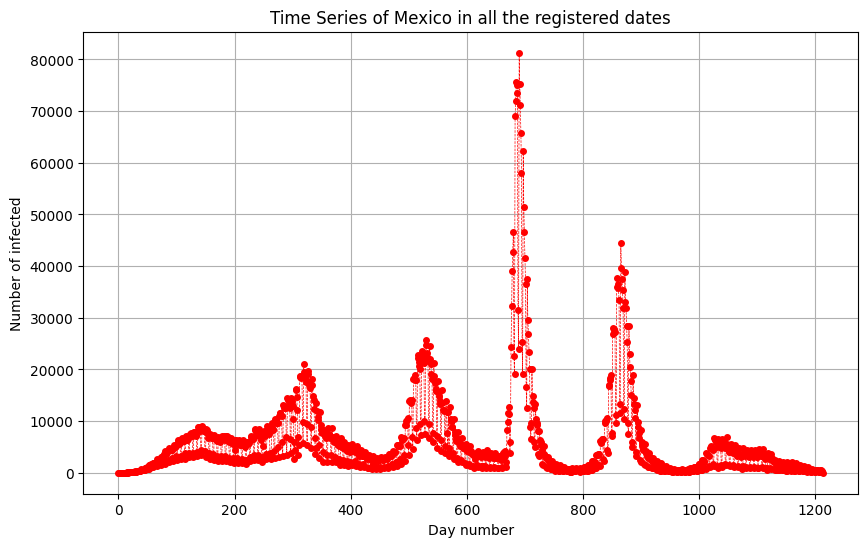

In [12]:
#Realizar la gráfica de los casos registrados en todo México
figure(figsize=(10,6))
grid()
title("Time Series of Mexico in all the registered dates")
xlabel("Day number")
ylabel("Number of infected")
t_days = arange(0,len(series_mexico),1)
plot(t_days,series_mexico,linewidth=0.5,markersize=4.0,color='red',linestyle="--",marker="o")

In [13]:
#Quedarnos únicamente con los datos de registros por día de cada estado
#Nos debemos quedar con los datos a partir de la fila con índice 4  y remover la última columna referente a casos totales de México
data = zeros((n-4,m-1))
data = mat2[4:n,0:m-1]

**Se considerarán las primeras 3 oleadas de COVID-19 en México. La primera y segunda comprenden del día 0 al 420. La tercera comprende del 421 al 643. Y la cuarta del día 644 al 764.**

#Cuarta oleada de COVID-19 en México

In [14]:
#El 1 de diciembre de 2021 corresponde al día 644
#El 28 de febrero de 2022 corresponde al índice 733
#El 31 de marzo de 2022 corresponde al índice 764
dia_ini4, dia_fin4 = 614,794
data_period4 = zeros((dia_fin4-dia_ini4,32))
data_period4 = data[dia_ini4:dia_fin4+1,:]

<Figure size 800x500 with 0 Axes>

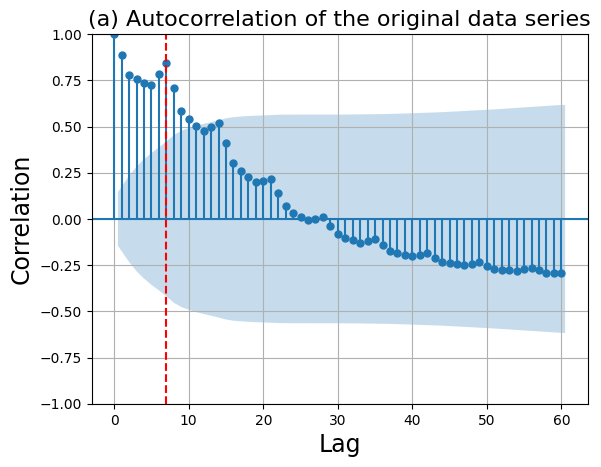

In [15]:
unique_series = apply_along_axis(sum,1,data_period4)
#Correlación cruzada entre las series de tiempo con desfases en un intervalo grande
figure(figsize=(8,5))
number_lags = 60
sm.graphics.tsa.plot_acf(unique_series, lags=number_lags)
axvline(x=7, linestyle="--", color= 'red')

title("(a) Autocorrelation of the original data series", fontsize=16)
xlabel("Lag", fontsize=17)
ylabel("Correlation", fontsize=17)
grid()
savefig('autocorrelation_data_states.png', dpi=350)

Determinar qué cantidad de unidades de tiempo seleccionar para aplicar las medias móviles centradas

In [16]:
#Número de estados
n_est = len(name_state)

#Lista para guardar la media de las desviaciones estándar de las derivadas de cada conjunto de series suavizadas con medias móviles
list_medias_std = []
#Lista para guardar la media de las desviaciones estándar de las derivadas de cada conjunto de series suavizadas con medianas móviles
list_medianas_std = []

#Probar con diferentes valores impares de k
for k in range(3,30,2):
    #Número de días de las series de tiempo suavizadas
    n_suav_k = dia_fin4-dia_ini4-k+2
    #Matriz de series de tiempo suavizadas con medias móviles
    mat_suav_k = zeros((n_est,n_suav_k))
    #Matriz de series de tiempo suavizadas con medianas móviles
    mat_suav_med_k = zeros((n_est,n_suav_k))
    for i in range(0,n_est):
        mat_suav_k[i,:] = media_movil(data_period4[:,i],k)
        mat_suav_med_k[i,:] = mediana_movil(data_period4[:,i],k)
    
    #Diferenciar las filas de la matriz mat_suav_k
    diff_mat_k = diff(mat_suav_k)
    arr_std_k = apply_along_axis(std,1,diff_mat_k)
    list_medias_std.append(mean(arr_std_k))
    #Diferenciar las filas de la matriz mat_suav_med_k
    diff_mat_med_k = diff(mat_suav_med_k)
    arr_std_med_k = apply_along_axis(std,1,diff_mat_med_k)
    list_medianas_std.append(mean(arr_std_med_k))

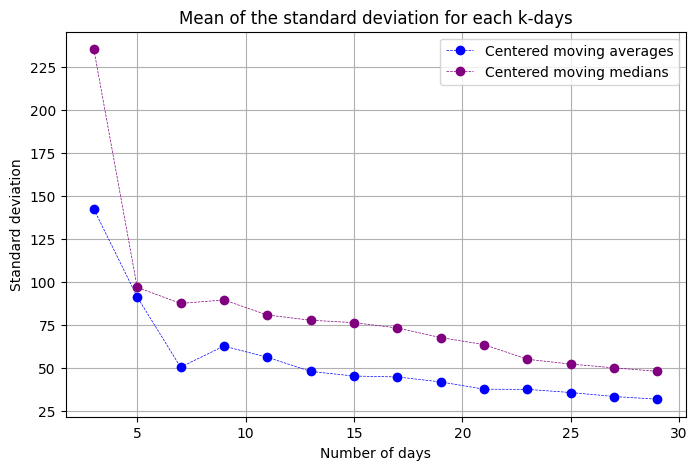

In [17]:
k_vec = arange(3,30,2)
figure(figsize=(8,5))
grid()
title("Mean of the standard deviation for each k-days")
xlabel("Number of days")
ylabel("Standard deviation")
plot(k_vec, list_medias_std, linewidth = 0.5, color = 'blue', linestyle = "--", marker = "o", label='Centered moving averages')
plot(k_vec, list_medianas_std, linewidth = 0.5, color = 'purple', linestyle = "--", marker = "o", label='Centered moving medians')
legend()
savefig('sd_data_states.png', dpi=350)

Cuarta oleada de COVID-19 en México suavizada

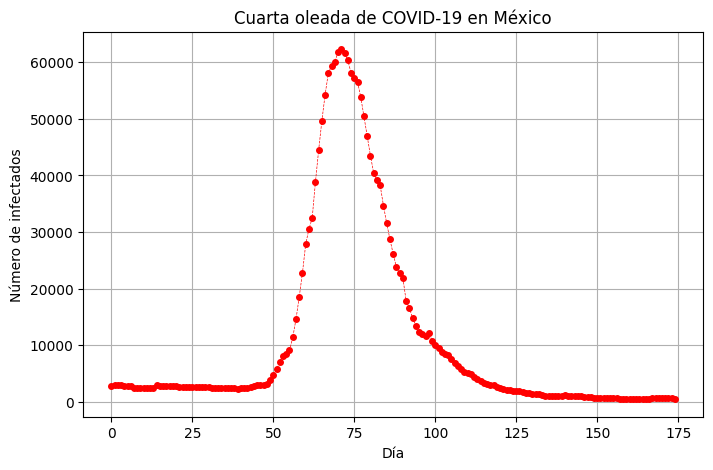

In [18]:
series_cuarta_mexico = media_movil(series_mexico[dia_ini4:dia_fin4+1],7)
figure(figsize=(8,5))
grid()
title("Cuarta oleada de COVID-19 en México")
xlabel("Día")
ylabel("Número de infectados")
t_days = arange(0,len(series_cuarta_mexico),1)
plot(t_days,series_cuarta_mexico,linewidth=0.5,markersize=4.0,color='red',linestyle="--",marker="o")
savefig("Cuarta_oleada_mex.png", dpi=350)

Suavizar las series de tiempo con el  k  elegido

In [19]:
k_selec = 7
#Número de días de las series de tiempo suavizadas
n_suav = dia_fin4-dia_ini4+1-k_selec+1
#Hacer pruebas con las series de tiempo suavizadas con medias móviles
#Matriz de series de tiempo suavizadas
mat_per_suav4 = zeros((n_suav, n_est))

for i in range(0,n_est):
    mat_per_suav4[:, i] = media_movil(data_period4[:,i],k_selec)

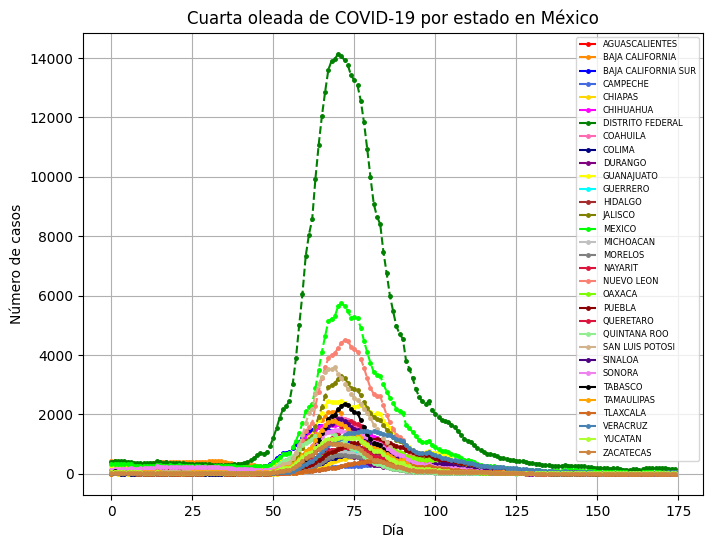

In [20]:
#Convertir la matriz de series de tiempo suavizadas a listas
ser_list = conv_to_list(mat_per_suav4)

#Graficar las series de tiempo suavizadas con medias móviles de 3 semanas
#Dos de las series no son estacionarias, así que se tuvieron que diferenciar las 4
figure(figsize = (8,6))
for i in range(0,n_est):
    plot(mat_per_suav4[:,i], linestyle = "--", marker = "o", markersize=2.5, label=name_state[i], color=list_colors[i])
grid()
legend(fontsize=6)

#xlabel("Day")
#ylabel("Number of cases")
#title("Registered cases of COVID-19 per state")
xlabel("Día")
ylabel("Número de casos")
title("Cuarta oleada de COVID-19 por estado en México")
savefig("Cuarta_oleada_estados.png", dpi=350)

In [21]:
#Imprimir nombres de los estados junto con sus etiquetas
for j in range(0,n_est):
  print(str(j)+" "+name_state[j])

0 AGUASCALIENTES
1 BAJA CALIFORNIA
2 BAJA CALIFORNIA SUR
3 CAMPECHE
4 CHIAPAS
5 CHIHUAHUA
6 DISTRITO FEDERAL
7 COAHUILA
8 COLIMA
9 DURANGO
10 GUANAJUATO
11 GUERRERO
12 HIDALGO
13 JALISCO
14 MEXICO
15 MICHOACAN
16 MORELOS
17 NAYARIT
18 NUEVO LEON
19 OAXACA
20 PUEBLA
21 QUERETARO
22 QUINTANA ROO
23 SAN LUIS POTOSI
24 SINALOA
25 SONORA
26 TABASCO
27 TAMAULIPAS
28 TLAXCALA
29 VERACRUZ
30 YUCATAN
31 ZACATECAS


In [22]:
id_state_new = [1,2,17,13,0,10,21,12,15,14,6,8,16,30,3,20,22,28,11,19,26,4,25,5,7,24,9,31,23,18,27,29]
mun_mex_map['coords'] = mun_mex_map['geometry'].apply(lambda x: x.representative_point().coords[:])
mun_mex_map['coords'] = [coords[0] for coords in mun_mex_map['coords']]
#Add new state label
mun_mex_map['id_new'] = id_state_new

## **K-means usando la distancia euclidiana**

In [23]:
euc_dist = matriz_euclid(mat_per_suav4)

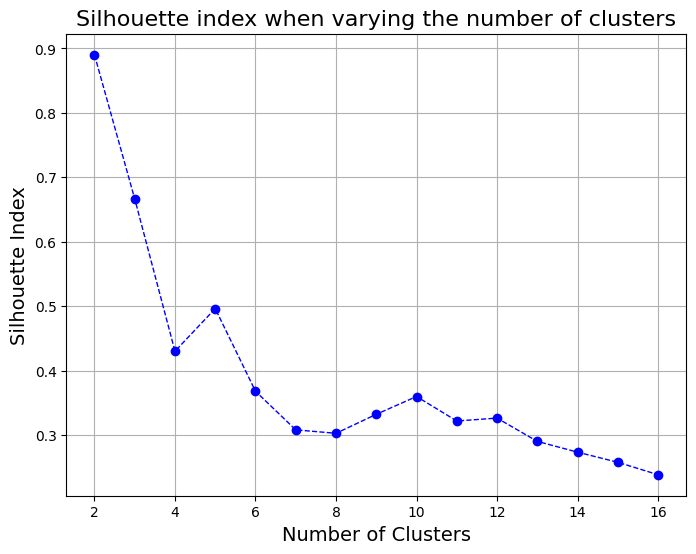

In [24]:
silhouette_list = []
for i in range(2,int(n_est/2)+1):
    kmeans_euc = KMeans(n_clusters=i, random_state=0, n_init='auto').fit(euc_dist)
    clust_euc = kmeans_euc.labels_
    clust_list_euc = sep_clust(clust_euc,i)
    #Compute silhouette index for the generated partition
    silhouette_list.append(silhouette_score(euc_dist,clust_euc))

figure(figsize= (8,6))
plot(range(2,int(n_est/2)+1),silhouette_list,linestyle="--",marker="o",markersize=6,linewidth=1.0,color='blue')
ylabel("Silhouette Index", fontsize=14)
xlabel("Number of Clusters", fontsize=14)
title("Silhouette index when varying the number of clusters", fontsize=16)
grid()

Seleccionamos $k=5$

In [25]:
n_clust = 5

kmeans_euc = KMeans(n_clusters=n_clust, random_state=0, n_init='auto').fit(euc_dist)
clust_euc = kmeans_euc.labels_
clust_list_euc = sep_clust(clust_euc,5)
print("Clustering obtenido:")
print(clust_list_euc)
print()
imp_names(clust_list_euc, name_state)

Clustering obtenido:
[[0, 3, 4, 8, 9, 11, 12, 15, 16, 17, 19, 20, 28, 31], [6], [14, 18], [1, 2, 5, 7, 21, 22, 24, 25, 26, 27, 29, 30], [10, 13, 23]]

Cluster 0
['AGUASCALIENTES', 'CAMPECHE', 'CHIAPAS', 'COLIMA', 'DURANGO', 'GUERRERO', 'HIDALGO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'OAXACA', 'PUEBLA', 'TLAXCALA', 'ZACATECAS']
Cluster 1
['DISTRITO FEDERAL']
Cluster 2
['MEXICO', 'NUEVO LEON']
Cluster 3
['BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR', 'CHIHUAHUA', 'COAHUILA', 'QUERETARO', 'QUINTANA ROO', 'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'VERACRUZ', 'YUCATAN']
Cluster 4
['GUANAJUATO', 'JALISCO', 'SAN LUIS POTOSI']


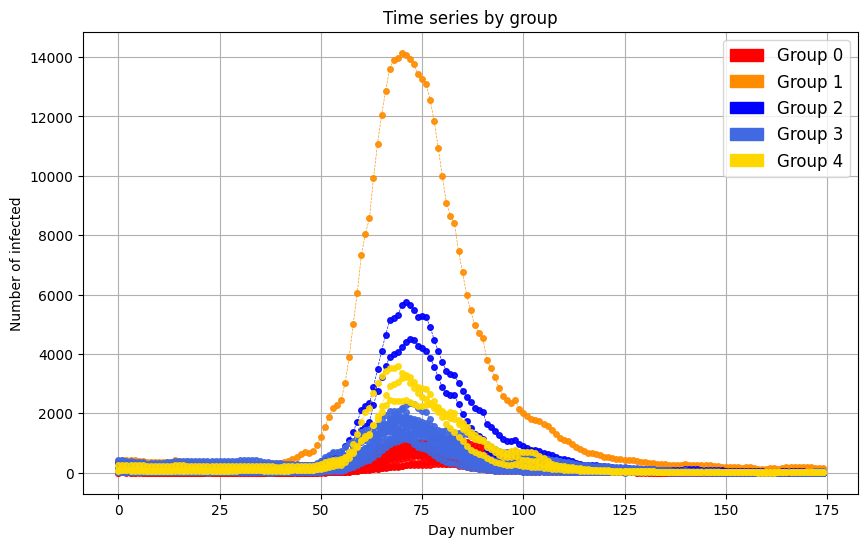

In [26]:
n1 = shape(mat_per_suav4)[0]
#Rango de días representados
days_time_serie = arange(0,n1,1)

days_time_serie = arange(0,n1,1)

figure(figsize=(10,6))
grid()
title("Time series by group")
xlabel("Day number")
ylabel("Number of infected")
#Número de comunidades
patches = []
#Graficar la serie de tiempo que corresponde a cada grupo
for k in range(0,n_clust):
    clust_act = clust_list_euc[k]
    len_act = len(clust_act)
    for l in range(0,len_act):
        plot(days_time_serie, mat_per_suav4[:,clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[k], linestyle="--", marker="o", alpha=0.9)
    patch_act = mpatches.Patch(color=list_colors[k], label='Group '+str(k))
    patches.append(patch_act)
legend(handles=patches,prop={'size':12})
#savefig('series_groups_euc_norm.png', dpi=600)

## K-Means utilizando la distancia Dynamic Time Warping (DTW)

In [27]:
dtw_dist = matriz_dtw(mat_per_suav4)

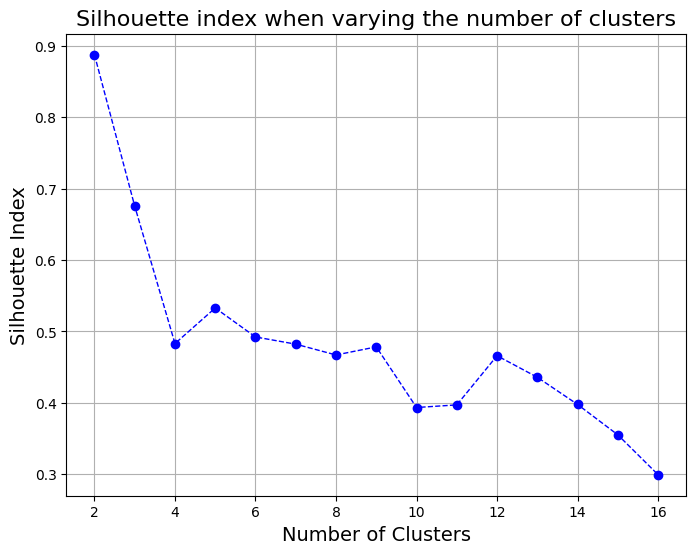

In [28]:
silhouette_list = []
for i in range(2,int(n_est/2)+1):
    kmeans_dtw = KMeans(n_clusters=i, random_state=0, n_init='auto').fit(dtw_dist)
    clust_dtw = kmeans_dtw.labels_
    clust_list_dtw = sep_clust(clust_dtw,i)
    #Compute silhouette index for the generated partition
    silhouette_list.append(silhouette_score(dtw_dist,clust_dtw))

figure(figsize= (8,6))
plot(range(2,int(n_est/2)+1),silhouette_list,linestyle="--",marker="o",markersize=6,linewidth=1.0,color='blue')
ylabel("Silhouette Index", fontsize=14)
xlabel("Number of Clusters", fontsize=14)
title("Silhouette index when varying the number of clusters", fontsize=16)
grid()

Seleccionamos $k=5$

In [29]:
kmeans_dtw = KMeans(n_clusters=5, random_state=0, n_init='auto').fit(dtw_dist)
clust_dtw = kmeans_dtw.labels_
clust_list_dtw = sep_clust(clust_dtw,5)
print("Clustering obtenido:")
print(clust_list_dtw)
print()
imp_names(clust_list_dtw, name_state)

Clustering obtenido:
[[0, 3, 4, 8, 9, 11, 12, 15, 16, 17, 19, 20, 28, 30, 31], [6], [14, 18], [1, 2, 5, 7, 21, 22, 24, 25, 26, 27, 29], [10, 13, 23]]

Cluster 0
['AGUASCALIENTES', 'CAMPECHE', 'CHIAPAS', 'COLIMA', 'DURANGO', 'GUERRERO', 'HIDALGO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'OAXACA', 'PUEBLA', 'TLAXCALA', 'YUCATAN', 'ZACATECAS']
Cluster 1
['DISTRITO FEDERAL']
Cluster 2
['MEXICO', 'NUEVO LEON']
Cluster 3
['BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR', 'CHIHUAHUA', 'COAHUILA', 'QUERETARO', 'QUINTANA ROO', 'SINALOA', 'SONORA', 'TABASCO', 'TAMAULIPAS', 'VERACRUZ']
Cluster 4
['GUANAJUATO', 'JALISCO', 'SAN LUIS POTOSI']


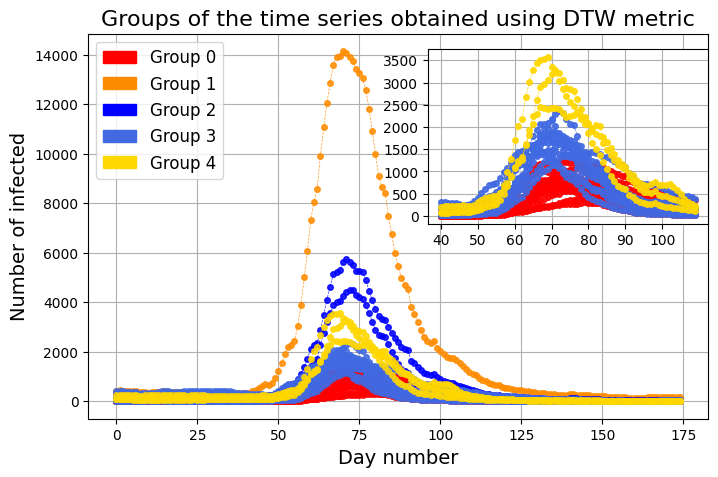

In [30]:
fig1 = figure(figsize=(8,5))
ax1 = fig1.add_subplot(111)
ax1.grid()
ax1.set_title("Groups of the time series obtained using DTW metric", fontsize=16)
xlabel("Day number", fontsize=14)
ylabel("Number of infected", fontsize=14)
ax2 = axes([.55, .5, .35, .35])
ax2.grid()

patches = []
#Graficar la serie de tiempo que corresponde a cada grupo
for k in range(0,n_clust):
    clust_act = clust_list_dtw[k]
    len_act = len(clust_act)
    for l in range(0,len_act):
        ax1.plot(days_time_serie, mat_per_suav4[:, clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[k], linestyle="--", marker="o", alpha=0.85)
        if k != 1 and k != 2:
            ax2.plot(days_time_serie[40:110], mat_per_suav4[40:110, clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[k], linestyle="--", marker="o", alpha=0.9)
    patch_act = mpatches.Patch(color=list_colors[k], label='Group '+str(k))
    patches.append(patch_act)

setp(ax2, xticks=arange(40,110,10), yticks=arange(0,4000,500))
ax1.legend(handles=patches,prop={'size':12}, loc = 'upper left')
savefig('series_groups_dtw_states.png', dpi=350)

Mapa de los estados agrupados de acuerdo al impacto de la epidemia o a la forma del brote epidémico

In [31]:
clust_new = transf(clust_list_dtw)
groups_per = com_to_group(clust_new)
#Lista colores a usar para las comunidades
colors_per5 = change(groups_per, list_colors[0:n_clust])

[<matplotlib.patches.Patch object at 0x79802c6b2c10>, <matplotlib.patches.Patch object at 0x79802c6b2d50>, <matplotlib.patches.Patch object at 0x79802c6b2e90>, <matplotlib.patches.Patch object at 0x79802c6b2fd0>, <matplotlib.patches.Patch object at 0x79802c6b3110>]


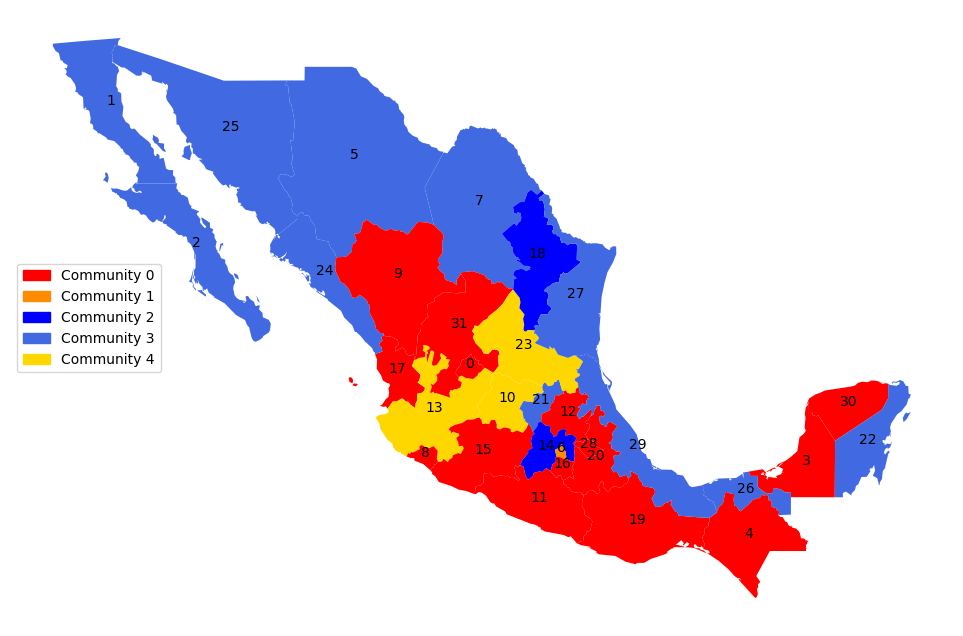

In [32]:
#Colorear mapa
fig,ax = subplots(figsize = (14,8))
#Asignar etiquetas de comunidades a colores
color_patches = generar_patches(list_colors[0:n_clust])
print(color_patches)
ax.legend(handles = color_patches, loc=6)
ax.axis('off')
#mun_mex_map.plot(color = colors_per,ax=ax)
ax1 = mun_mex_map.plot(color = colors_per5,ax=ax)
mun_mex_map.apply(lambda x: ax1.annotate(text=x['id_new'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1)
savefig('map_states_DTW.png', dpi=350)

## K-Means utilizando la distancia Move–split–merge (MSM)

In [33]:
msm_dist = matriz_msm(mat_per_suav4)

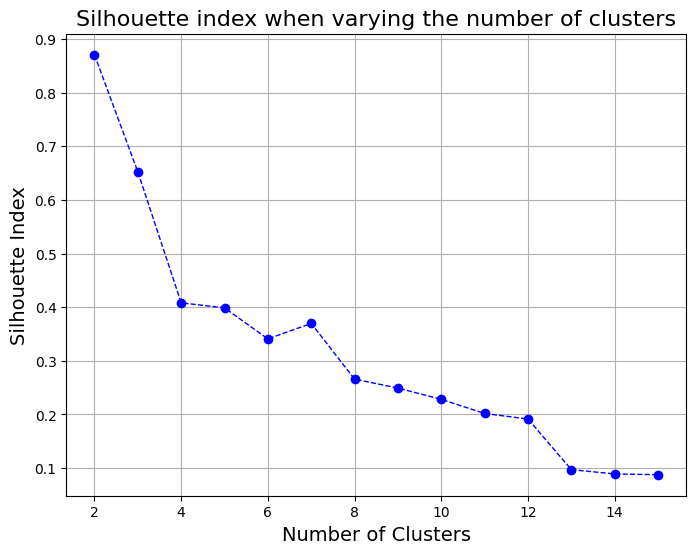

In [34]:
silhouette_list = []
for i in range(2,int(n_est/2)):
    kmeans_msm = KMeans(n_clusters=i, random_state=0, n_init='auto').fit(msm_dist)
    clust_msm = kmeans_msm.labels_
    clust_list_msm = sep_clust(clust_msm,i)
    #Compute silhouette index for the generated partition
    silhouette_list.append(silhouette_score(msm_dist,clust_msm))

figure(figsize = (8,6))
plot(range(2,int(n_est/2)), silhouette_list, linestyle="--", marker="o", markersize=6, linewidth=1.0, color='blue')
ylabel("Silhouette Index", fontsize=14)
xlabel("Number of Clusters", fontsize=14)
title("Silhouette index when varying the number of clusters", fontsize=16)
grid()

Seleccionamos $k=4$

In [35]:
n_clust = 4

kmeans_msm = KMeans(n_clusters=n_clust, random_state=0, n_init='auto').fit(msm_dist)
clust_msm = kmeans_msm.labels_
clust_list_msm = sep_clust(clust_msm,4)
print("Clustering obtenido:")
print(clust_list_msm)
print()
imp_names(clust_list_msm, name_state)

Clustering obtenido:
[[0, 2, 3, 4, 8, 9, 11, 12, 15, 16, 17, 19, 20, 21, 22, 25, 28, 29, 30, 31], [6], [14, 18, 23], [1, 5, 7, 10, 13, 24, 26, 27]]

Cluster 0
['AGUASCALIENTES', 'BAJA CALIFORNIA SUR', 'CAMPECHE', 'CHIAPAS', 'COLIMA', 'DURANGO', 'GUERRERO', 'HIDALGO', 'MICHOACAN', 'MORELOS', 'NAYARIT', 'OAXACA', 'PUEBLA', 'QUERETARO', 'QUINTANA ROO', 'SONORA', 'TLAXCALA', 'VERACRUZ', 'YUCATAN', 'ZACATECAS']
Cluster 1
['DISTRITO FEDERAL']
Cluster 2
['MEXICO', 'NUEVO LEON', 'SAN LUIS POTOSI']
Cluster 3
['BAJA CALIFORNIA', 'CHIHUAHUA', 'COAHUILA', 'GUANAJUATO', 'JALISCO', 'SINALOA', 'TABASCO', 'TAMAULIPAS']


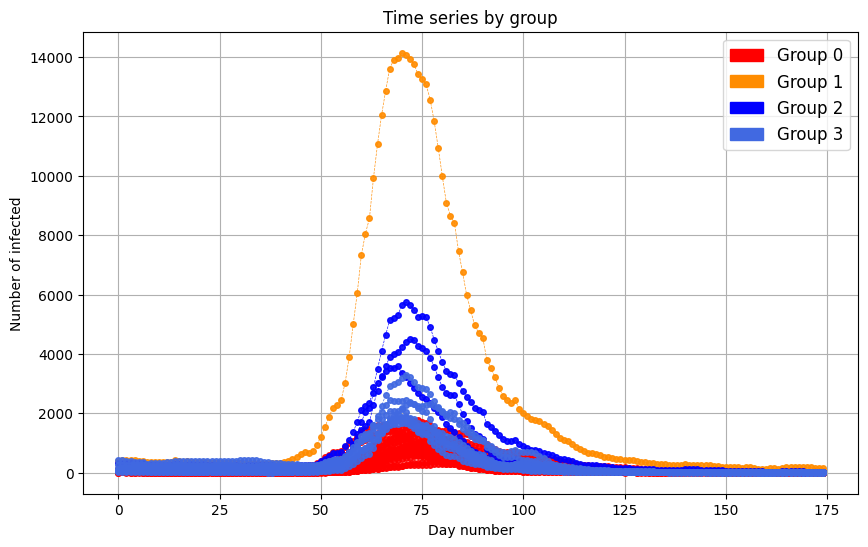

In [36]:
figure(figsize=(10,6))
grid()
title("Time series by group")
xlabel("Day number")
ylabel("Number of infected")
#Número de comunidades
patches = []
#Graficar la serie de tiempo que corresponde a cada grupo
for k in range(0,n_clust):
    clust_act = clust_list_msm[k]
    len_act = len(clust_act)
    for l in range(0,len_act):
        plot(days_time_serie, mat_per_suav4[:, clust_act[l]], linewidth=0.5, markersize=4.0, color=list_colors[k], linestyle="--", marker="o", alpha=0.9)
    patch_act = mpatches.Patch(color=list_colors[k], label='Group '+str(k))
    patches.append(patch_act)
legend(handles=patches, prop={'size':12})
#savefig('series_groups_msm.png', dpi=600)